In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [14]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()
metadata_20x_filt = metadata_20x_filt.loc[metadata_20x_filt.species_genotyping.isin(used_species)]

In [3]:
df_l = []
for s in used_species:
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    if sum(pi_df.chr_type == "chrX") < 10 or sum(pi_df.chr_type == "aut") < 10:
        print("Too little data", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [15]:
for ref in metadata_20x_filt.reference.unique():
    print(ref, len(metadata_20x_filt.loc[metadata_20x_filt.reference == ref].species_genotyping.unique()))

Allenopithecus_nigroviridis 1
Aotus_nancymaae 5
Ateles_hybridus 12
Callimico_goeldii 1
Callithrix_jacchus 5
Cercopithecus_mitis 12
Cheirogaleus_medius 3
Chlorocebus_sabaeus 3
Colobus_guereza 2
Daubentonia_madagascariensis 1
Eulemur_flavifrons 3
Eulemur_rufifrons 4
Gorilla_gorilla 2
Hoolock_leuconedys 2
Hylobates_pileatus 3
Lemur_catta 4
Leontopithecus_rosalia 1
Macaca_fascicularis 1
Macaca_mulatta 4
Macaca_nemestrina 8
Macaca_thibetana 5
Mandrillus_sphinx 4
Microcebus_murinus 9
Miopithecus_talapoin 1
Nasalis_larvatus 1
Nomascus_leucogenys 2
Nycticebus_coucang 7
Otolemur_crassicaudatus 5
Pan_paniscus 1
Pan_troglodytes 1
Papio_anubis 7
Pithecia_pithecia 11
Plecturocebus_cupreus 12
Pongo_abelii 1
Pongo_pygmaeus 1
Propithecus_coquereli 6
Rhinopithecus_roxellana 9
Saguinus_oedipus 7
Saimiri_boliviensis 5
Sapajus_apella 5
Symphalangus_syndactylus 1
Theropithecus_gelada 1
Trachypithecus_francoisi 13
Varecia_variegata 1


In [42]:
# Test with various speces references
for ref in ["Cercopithecus_mitis"]:
    species = metadata_20x_filt.loc[metadata_20x_filt.reference == ref].species_genotyping.unique()
    x_m = np.ones((len(species), len(species)))
    aut_m = np.ones((len(species), len(species)))
    if len(species) == 1:
        continue
    for i in range(len(species)):
        for j in range(i+1):
            s1 = species[i]
            s2 = species[j]
            merged_df = pd.merge(all_pi_df.loc[(all_pi_df.species == s1) & (all_pi_df.callable_frac >= 0.5)],
                    all_pi_df.loc[(all_pi_df.species == s2) & (all_pi_df.callable_frac >= 0.5)],
                    on=["chrom", "window_start"])
            merged_df_x = merged_df.loc[merged_df.chr_type_x == "chrX"]
            cor_x = merged_df_x[["pi_x", "pi_y"]].corr().iloc[0, 1]
            x_m[i, j] = cor_x
            x_m[j, i] = cor_x
            merged_df_aut = merged_df.loc[merged_df.chr_type_x == "aut"]
            cor_aut = merged_df_aut[["pi_x", "pi_y"]].corr().iloc[0, 1]
            aut_m[i, j] = cor_aut
            aut_m[j, i] = cor_aut

<Axes: >

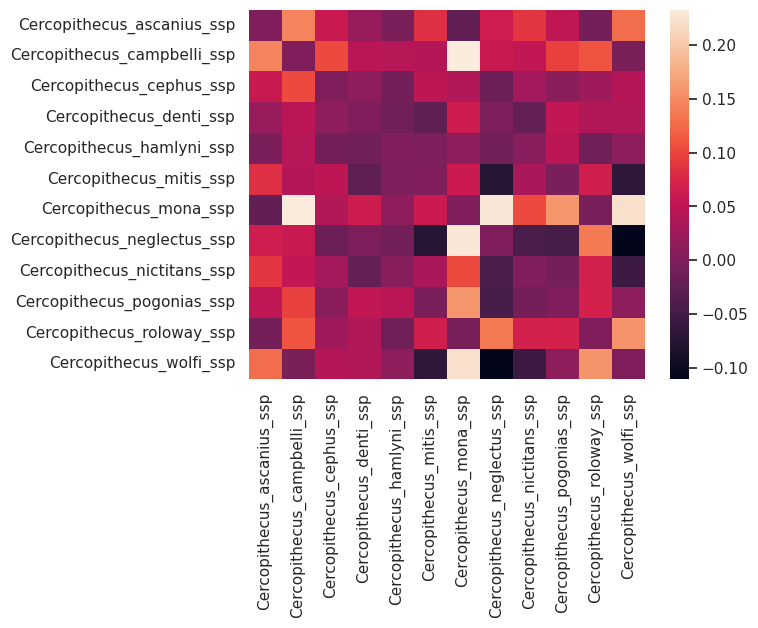

In [43]:
sns.heatmap(aut_m-x_m, xticklabels=species, yticklabels=species)

In [47]:
aut_m

array([[1.        , 0.74493632, 0.94254031, 0.61028369, 0.70167975,
        0.78611196, 0.74858619, 0.52081319, 0.75133134, 0.71557647,
        0.63699889, 0.61334719],
       [0.74493632, 1.        , 0.75729976, 0.63607218, 0.68340446,
        0.71289518, 0.8104014 , 0.60798445, 0.71941316, 0.73035262,
        0.59157471, 0.65758506],
       [0.94254031, 0.75729976, 1.        , 0.61324215, 0.70393763,
        0.78889402, 0.75513208, 0.54208144, 0.76403404, 0.72619286,
        0.63685036, 0.62013452],
       [0.61028369, 0.63607218, 0.61324215, 1.        , 0.54963194,
        0.59813595, 0.62840861, 0.48901013, 0.60302557, 0.66071925,
        0.49254839, 0.74930937],
       [0.70167975, 0.68340446, 0.70393763, 0.54963194, 1.        ,
        0.67314579, 0.65799148, 0.50265942, 0.6510451 , 0.62842553,
        0.55890117, 0.54869232],
       [0.78611196, 0.71289518, 0.78889402, 0.59813595, 0.67314579,
        1.        , 0.70223983, 0.52385712, 0.80533828, 0.67056857,
        0.57997043,

In [48]:
x_m

array([[1.        , 0.60031525, 0.88347327, 0.59034891, 0.70641939,
        0.70246948, 0.77246741, 0.45699255, 0.66268911, 0.66536704,
        0.6451294 , 0.48556321],
       [0.60031525, 1.        , 0.65398262, 0.58882477, 0.63871616,
        0.67055369, 0.57798115, 0.54957229, 0.66659026, 0.63364028,
        0.48148213, 0.65984693],
       [0.88347327, 0.65398262, 1.        , 0.6007263 , 0.71217171,
        0.73977188, 0.71523047, 0.55847733, 0.73593877, 0.71766601,
        0.61331504, 0.57734619],
       [0.59034891, 0.58882477, 0.6007263 , 1.        , 0.56119894,
        0.62334785, 0.56523727, 0.49035883, 0.62466649, 0.60910143,
        0.45301761, 0.70886771],
       [0.70641939, 0.63871616, 0.71217171, 0.56119894, 1.        ,
        0.67481137, 0.64420223, 0.51176816, 0.64495819, 0.58219402,
        0.57095428, 0.53710575],
       [0.70246948, 0.67055369, 0.73977188, 0.62334785, 0.67481137,
        1.        , 0.64204899, 0.59899891, 0.77164216, 0.67399816,
        0.5147335 ,

In [49]:
aut_m-x_m

array([[ 0.        ,  0.14462106,  0.05906705,  0.01993479, -0.00473964,
         0.08364248, -0.02388122,  0.06382064,  0.08864223,  0.05020944,
        -0.00813051,  0.12778398],
       [ 0.14462106,  0.        ,  0.10331714,  0.0472474 ,  0.0446883 ,
         0.04234149,  0.23242025,  0.05841217,  0.0528229 ,  0.09671233,
         0.11009258, -0.00226187],
       [ 0.05906705,  0.10331714,  0.        ,  0.01251586, -0.00823408,
         0.04912214,  0.03990161, -0.01639589,  0.02809527,  0.00852685,
         0.02353532,  0.04278833],
       [ 0.01993479,  0.0472474 ,  0.01251586,  0.        , -0.011567  ,
        -0.0252119 ,  0.06317133, -0.00134871, -0.02164093,  0.05161782,
         0.03953078,  0.04044166],
       [-0.00473964,  0.0446883 , -0.00823408, -0.011567  ,  0.        ,
        -0.00166558,  0.01378925, -0.00910874,  0.00608691,  0.04623151,
        -0.01205312,  0.01158657],
       [ 0.08364248,  0.04234149,  0.04912214, -0.0252119 , -0.00166558,
         0.        ,  

While interesting, there is a high likelihood that there is shared variation either through shared ancestry or admixture, so the more interesting question is whether there is a correlation across fully unrelated species.